<a href="https://colab.research.google.com/github/davidrpugh/introduction-to-deep-learning/blob/master/notebooks/01b-mlp-for-regression-with-pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Layer Perceptrons (MLPs) for Regression with PyTorch

In [84]:
import numpy as np
import torch
from torch import nn, optim

from sklearn import compose, datasets, neural_network, metrics, model_selection
from sklearn import pipeline, preprocessing

## Load the California Housing dataset

In [85]:
housing_dataset = datasets.fetch_california_housing(
    as_frame=True
)

In [86]:
print(housing_dataset["DESCR"])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [87]:
housing_features_df = housing_dataset["data"]
median_house_value = housing_dataset["target"]

In [88]:
housing_features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


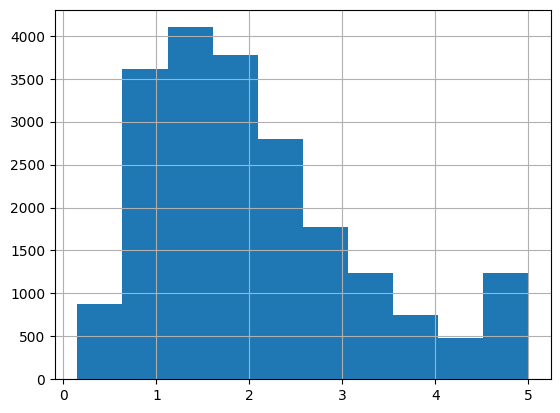

In [89]:
_ = median_house_value.hist()

## Train/Val Split

In [90]:
RANDOM_STATE = np.random.RandomState(42)


train_features_df, val_features_df, train_target, val_target = (
    model_selection.train_test_split(
        housing_features_df,
        median_house_value,
        test_size=0.20,
        shuffle=True,
        random_state=RANDOM_STATE
    )
)


In [91]:
train_features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      16512 non-null  float64
 1   HouseAge    16512 non-null  float64
 2   AveRooms    16512 non-null  float64
 3   AveBedrms   16512 non-null  float64
 4   Population  16512 non-null  float64
 5   AveOccup    16512 non-null  float64
 6   Latitude    16512 non-null  float64
 7   Longitude   16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


In [92]:
val_features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4128 entries, 20046 to 3665
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      4128 non-null   float64
 1   HouseAge    4128 non-null   float64
 2   AveRooms    4128 non-null   float64
 3   AveBedrms   4128 non-null   float64
 4   Population  4128 non-null   float64
 5   AveOccup    4128 non-null   float64
 6   Latitude    4128 non-null   float64
 7   Longitude   4128 non-null   float64
dtypes: float64(8)
memory usage: 290.2 KB


## Prepare the data

In [93]:
def array_to_tensor(arr, dtype=torch.float32):
  return torch.tensor(arr, dtype=dtype)


def dataframe_to_tensor(df, dtype=torch.float32):
    arr = df.to_numpy()
    return array_to_tensor(arr, dtype)


def series_to_tensor(s, dtype=torch.float32):
    df = s.to_frame()
    return dataframe_to_tensor(df, dtype)


prepare_housing_features = pipeline.make_pipeline(
    preprocessing.QuantileTransformer(),
    preprocessing.FunctionTransformer(
        func=array_to_tensor
    )
)

prepare_housing_target = pipeline.make_pipeline(
    preprocessing.FunctionTransformer(
        func=series_to_tensor
    )
)



In [94]:
X_train = prepare_housing_features.fit_transform(train_features_df)
X_val = prepare_housing_features.transform(val_features_df)


In [96]:
print(X_train.shape)
print(X_val.shape)

torch.Size([16512, 8])
torch.Size([4128, 8])


In [95]:
y_train = prepare_housing_target.fit_transform(train_target)
y_val = prepare_housing_target.transform(val_target)


In [97]:
print(y_train.shape)
print(y_val.shape)

torch.Size([16512, 1])
torch.Size([4128, 1])


## Implementing a MLP for Regression using nn.Sequential

[`nn.Sequential`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html) in PyTorch is a container module that allows for the sequential execution of a series of neural network layers or modules. It simplifies the process of building neural networks with a linear, feed-forward structure by eliminating the need to explicitly define the forward method for each layer.


### Key Characteristics and Use-Cases

* **Ordered Container:** `nn.Sequential` takes a list of `nn.Module` instances (layers) and arranges them in the order they are provided.
* **Automatic Forward Pass:** When an input tensor is passed to an `nn.Sequential` object, it automatically propagates through each contained module in the defined order, with the output of one module serving as the input to the next.
* **Simplified Model Definition:** It offers a concise way to define models, especially for straightforward architectures without complex branching or custom logic within the forward pass.
* **Treat as a Single Module:** The entire `nn.Sequential` container can be treated as a single `nn.Module`, allowing for easy integration into larger models or for applying operations like moving to a device (`.to(device)`) or setting training/evaluation mode (`.train()`, `.eval()`).

### Layer-by-Layer Explanation

1. **Input layer:**
  * Input: Number of inputs (`n_features`)
  * Output: Number of neurons in the first hidden layer (50 neurons) → a tunable hyperparameter
2. **Activation:**
  * [`nn.ReLU`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
  * Applies ReLU elementwise (no parameters, same input/output shape)
3. **Second hidden layer:**
  * Input: 50 neurons (must match previous output!)
  * Output: Number of neurons in the second hidden layer (40 neurons) → a tunable hyperparameter
4. **Activation:**
  * `nn.ReLU`
5. **Output layer:**
  * Input: 40 neurons (must match previous output!)
  * Output: 1 neuron (must match the regression target dimensionality!)

In [98]:
_ = torch.manual_seed(42)

_, n_features = X_train.shape
housing_model = nn.Sequential(
    nn.Linear(
        in_features=n_features,
        out_features=50,
        bias=True,
    ),
    nn.ReLU(),
    nn.Linear(50, 40),
    nn.ReLU(),
    nn.Linear(40, 1)
)


### Loss functions and optimizers

In [99]:
mse_loss = nn.MSELoss()

sgd = optim.SGD(
    housing_model.parameters(),
    lr=1e-2
)

### Define a training loop


In [101]:
def train(
    model_fn,
    criterion,
    optimizer,
    X_train,
    y_train,
    X_val,
    y_val,
    n_epochs,
    log_epochs=100,
    ):

    for epoch in range(n_epochs):
        # forward pass
        y_pred = model_fn(X_train)
        train_loss = criterion(y_pred, y_train)

        # backward pass
        train_loss.backward()

        # gradient descent step
        optimizer.step()
        optimizer.zero_grad()

        # evaluate using the validation data
        with torch.no_grad():
            y_pred = model_fn(X_val)
            val_loss = criterion(y_pred, y_val)

        if (epoch + 1) % log_epochs == 0:
            print(f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {train_loss.item(): .4f}, Val Loss: {val_loss.item(): .4f}")



In [102]:
train(
    housing_model,
    mse_loss,
    sgd,
    X_train,
    y_train,
    X_val,
    y_val,
    n_epochs=1000
)

Epoch 100/1000, Training Loss:  0.9331, Val Loss:  0.9133
Epoch 200/1000, Training Loss:  0.6966, Val Loss:  0.6866
Epoch 300/1000, Training Loss:  0.5855, Val Loss:  0.5841
Epoch 400/1000, Training Loss:  0.5412, Val Loss:  0.5443
Epoch 500/1000, Training Loss:  0.5149, Val Loss:  0.5202
Epoch 600/1000, Training Loss:  0.4966, Val Loss:  0.5037
Epoch 700/1000, Training Loss:  0.4834, Val Loss:  0.4916
Epoch 800/1000, Training Loss:  0.4728, Val Loss:  0.4820
Epoch 900/1000, Training Loss:  0.4641, Val Loss:  0.4739
Epoch 1000/1000, Training Loss:  0.4568, Val Loss:  0.4668


## Exercise (Optional):

Train a [`MLPRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html) from the Scikit-Learn `neural_network` package with the following settings.

 ```
 neural_network.MLPRegressor(
    early_stopping=True,
    hidden_layer_sizes=(50, 40),
    activation="relu",
    solver="sgd",
    max_iter=1000,
    random_state=RANDOM_STATE,
    verbose=True,
)
```

Compare the results to what you obtained using PyTorch above.

In [18]:
# INSERT YOUR CODE HERE!

### Solution:

In [104]:
mlp_regressor = pipeline.make_pipeline(
    prepare_housing_features[:-1],
    neural_network.MLPRegressor(
        early_stopping=True,
        hidden_layer_sizes=(50, 40),
        activation="relu",
        solver="sgd",
        max_iter=1000,
        random_state=RANDOM_STATE,
        verbose=True,
    )
)
_ = mlp_regressor.fit(train_features_df, train_target)


Iteration 1, loss = 1.21822366
Validation score: 0.138668
Iteration 2, loss = 0.53273974
Validation score: 0.252191
Iteration 3, loss = 0.46253175
Validation score: 0.347804
Iteration 4, loss = 0.40440463
Validation score: 0.425345
Iteration 5, loss = 0.35871323
Validation score: 0.483851
Iteration 6, loss = 0.32531321
Validation score: 0.526513
Iteration 7, loss = 0.30188871
Validation score: 0.555334
Iteration 8, loss = 0.28579086
Validation score: 0.575569
Iteration 9, loss = 0.27452816
Validation score: 0.590454
Iteration 10, loss = 0.26612553
Validation score: 0.601720
Iteration 11, loss = 0.25956855
Validation score: 0.608756
Iteration 12, loss = 0.25435414
Validation score: 0.617879
Iteration 13, loss = 0.24970981
Validation score: 0.624776
Iteration 14, loss = 0.24574556
Validation score: 0.630984
Iteration 15, loss = 0.24235681
Validation score: 0.635681
Iteration 16, loss = 0.23950314
Validation score: 0.640079
Iteration 17, loss = 0.23660627
Validation score: 0.643079
Iterat

In [108]:
train_prediction = mlp_regressor.predict(train_features_df)
train_mse = metrics.mean_squared_error(
    train_target,
    train_prediction
)

val_prediction = mlp_regressor.predict(val_features_df)
val_mse = metrics.mean_squared_error(
    val_target,
    val_prediction
)

print(f"Train Loss: {train_mse: .4f}, Val Loss: {val_mse: .4f}")

Train Loss:  0.3157, Val Loss:  0.3265
